# Slime Mold Algorithm — TSP classique

## Description

Le **Slime Mold Algorithm (SMA)** est une métaheuristique bio-inspirée (Li et al., 2020) imitant le comportement de propagation du *Physarum polycephalum* — un champignon capable de trouver des chemins courts dans des labyrinthes.

| Composant | Rôle |
|-----------|------|
| **Population d'agents** | Chaque agent = un tour complet |
| **Poids oscillatoires** | Formule log inspirée des oscillations du Physarum |
| **OX Crossover** | Croisement ordonné avec le meilleur agent + 2 aléatoires |
| **Random swap** | Perturbation si l'agent est proche du meilleur |
| **2-opt périodique** | Intensification locale par phase |
| **Arrêt anticipé** | Stoppe si le 2-opt ne progresse plus |

## Formule des poids

$$w_i = \begin{cases} 1 + r \cdot \log\!\left(\dfrac{bF - s_i}{bF - wF} + 1\right) & i < \lfloor P/2 \rfloor \quad\text{(meilleurs)} \\ 1 - r \cdot \log\!\left(\dfrac{bF - s_i}{bF - wF} + 1\right) & i \geq \lfloor P/2 \rfloor \quad\text{(moins bons)} \end{cases}$$

avec $bF$ = coût du meilleur, $wF$ = coût du pire, $r \sim \mathcal{U}(0,1)$.

## Règle de mise à jour d'un agent

$$p = \tanh(|s_i - bF|)$$

- Si $\text{rand} < p$ : **exploitation** → OX-crossover$(X_b,\, \text{OX-crossover}(X_A, X_B))$
- Sinon : **exploration** → swap aléatoire de deux villes

In [1]:
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

random.seed(42)
np.random.seed(42)

DATASETS_DIR = Path("datasets")

---
## 1. Chargement du dataset

Même convention que `pomo.ipynb` : poids bruts stockés dans `Graph`, coût rapporté avec **×200**.

In [2]:
def load_json_instance(path: Path) -> tuple[list[tuple[float, float]], dict]:
    """
    Charge un fichier tsptwd_n*.json.
    Retourne (cities, meta) où cities = liste de (x, y), dépôt en index 0.
    """
    with open(path) as f:
        data = json.load(f)
    nodes = [data["depot"]] + data["clients"]
    cities = [(nd["x"], nd["y"]) for nd in nodes]
    return cities, data["meta"]


def tour_cost(cities: list, tour: list[int], scale: float = 200) -> float:
    """
    Coût d'un tour hamiltonien cyclique, multiplié par scale.
    tour = [i0, i1, ..., in-1]  (sans répétition du point de départ)
    Identique à la convention turn_cost de Graph, avec le facteur ×200.
    """
    n = len(tour)
    total = sum(
        math.sqrt((cities[tour[i]][0] - cities[tour[(i+1) % n]][0])**2
                + (cities[tour[i]][1] - cities[tour[(i+1) % n]][1])**2)
        for i in range(n)
    )
    return round(total * scale, 1)


# ── Vérification ──────────────────────────────────────────────────────────
cities10, meta10 = load_json_instance(DATASETS_DIR / "tsptwd_n10.json")
print(f"n_clients : {meta10['n_clients']}   scale : {meta10['scale']}")
print(f"Exemple de ville 0 : {cities10[0]}")

n_clients : 10   scale : 200.0
Exemple de ville 0 : (0.8444218515250481, 0.7579544029403025)


---
## 2. Implémentation

In [3]:
class Graph:
    """Graphe complet euclidien. Les distances sont brutes (sans ×200)."""

    def __init__(self, cities: list[tuple[float, float]]):
        self.cities = cities
        self.n = len(cities)
        # Matrice de distances précalculée — élimine les appels répétés à sqrt()
        self.dist: list[list[float]] = [
            [
                math.sqrt((cities[i][0] - cities[j][0]) ** 2
                        + (cities[i][1] - cities[j][1]) ** 2)
                for j in range(self.n)
            ]
            for i in range(self.n)
        ]

    def distance(self, i: int, j: int) -> float:
        return self.dist[i][j]

    def turn_cost(self, turn: list[int]) -> float:
        """Coût brut (sans ×200) d'un tour cyclique."""
        dist = self.dist
        n = len(turn)
        return sum(dist[turn[i]][turn[(i + 1) % n]] for i in range(n))

    @classmethod
    def from_json(cls, path: Path) -> tuple["Graph", dict]:
        cities, meta = load_json_instance(path)
        return cls(cities), meta

In [4]:
class Agent:
    """Un agent = un tour hamiltonien + son coût brut + son poids."""

    def __init__(self, graph: Graph, turn: list[int]):
        self.graph = graph
        self.turn  = turn
        self.weight = 1.0
        self.cost   = graph.turn_cost(turn)

    @classmethod
    def random(cls, graph: Graph) -> "Agent":
        turn = list(range(graph.n))
        random.shuffle(turn)
        return cls(graph, turn)

In [5]:
def random_swap(turn: list[int]) -> list[int]:
    """Échange deux villes aléatoires."""
    tmp = turn[:]
    a, b = random.sample(range(len(turn)), 2)
    tmp[a], tmp[b] = tmp[b], tmp[a]
    return tmp


def ox_crossover(parent1: list[int], parent2: list[int]) -> list[int]:
    """
    Order Crossover (OX) : hérite d'un sous-segment de parent1,
    complète dans l'ordre de parent2.
    """
    n = len(parent1)
    a, b = sorted(random.sample(range(n), 2))

    child = [None] * n
    child[a:b] = parent1[a:b]
    placed = set(parent1[a:b])

    remaining = [v for v in parent2 if v not in placed]
    j = 0
    for i in range(n):
        if child[i] is None:
            child[i] = remaining[j]
            j += 1
    return child


def two_opt(turn: list[int], graph: Graph, max_passes: int = 5) -> list[int]:
    """
    2-opt avec matrice de distances précalculée et cache de ligne.
    Break après chaque amélioration, redémarre les deux boucles.
    """
    n    = len(turn)
    dist = graph.dist
    for _ in range(max_passes):
        improved = False
        for i in range(n - 1):
            di      = dist[turn[i]]
            di1     = dist[turn[i + 1]]
            d_i_i1  = di[turn[i + 1]]
            for j in range(i + 2, n):
                if i == 0 and j == n - 1:
                    continue  # même arête dans un tour cyclique
                gain = (d_i_i1 + dist[turn[j]][turn[(j + 1) % n]]
                      - di[turn[j]] - di1[turn[(j + 1) % n]])
                if gain > 1e-10:
                    turn[i + 1 : j + 1] = turn[i + 1 : j + 1][::-1]
                    improved = True
                    break
            if improved:
                break
        if not improved:
            break
    return turn

In [6]:
class Population:
    """
    Population de P agents pour le Slime Mold Algorithm.

    Paramètres
    ----------
    graph          : instance du problème
    nb_agents      : taille de la population (P)
    phase_length   : durée d'un cycle exploration + 2-opt (en itérations)
    opt_ratio      : fraction du cycle consacrée au 2-opt (ex. 0.25 → 25 %)
    max_opt_passes : passes 2-opt max par agent par itération d'optimisation
    warm_start     : si True, initialise depuis le tour NN + double-bridge (recommandé)
    """

    def __init__(
        self,
        graph: Graph,
        nb_agents: int,
        phase_length: int = 15,
        opt_ratio: float = 0.25,
        max_opt_passes: int = 5,
        warm_start: bool = True,
    ):
        self.graph          = graph
        self.nb_agents      = nb_agents
        self.phase_length   = phase_length
        self.opt_ratio      = opt_ratio
        self.max_opt_passes = max_opt_passes
        self.agents         = (self._warm_init() if warm_start
                               else [Agent.random(graph) for _ in range(nb_agents)])

    # ------------------------------------------------------------------
    # Initialisation warm-start
    # ------------------------------------------------------------------

    def _nn_tour(self) -> list[int]:
        """Tour Nearest-Neighbor depuis le dépôt (index 0) — utilise dist[][]."""
        g    = self.graph
        dist = g.dist
        visited = [False] * g.n
        tour = [0]; visited[0] = True
        for _ in range(g.n - 1):
            last   = tour[-1]
            d_last = dist[last]
            nxt    = min(
                (j for j in range(g.n) if not visited[j]),
                key=lambda j: d_last[j],
            )
            tour.append(nxt); visited[nxt] = True
        return tour

    def _double_bridge(self, tour: list[int]) -> list[int]:
        """Perturbation 4-opt double-bridge : A+B+C+D → A+C+B+D."""
        n = len(tour)
        if n < 8:
            return tour[:]
        a, b, c = sorted(random.sample(range(1, n), 3))
        return tour[:a] + tour[b:c] + tour[a:b] + tour[c:]

    def _warm_init(self) -> list[Agent]:
        """
        Warm start : 1 agent NN + (P-1) agents = NN perturbé par double-bridge + 2-opt.
        Donne un point de départ beaucoup plus proche de l'optimal que des tours aléatoires.
        """
        base = self._nn_tour()
        agents = [Agent(self.graph, base[:])]
        for _ in range(self.nb_agents - 1):
            t = two_opt(self._double_bridge(base), self.graph, max_passes=2)
            agents.append(Agent(self.graph, t))
        return agents

    # ------------------------------------------------------------------
    # Propriétés
    # ------------------------------------------------------------------

    @property
    def best(self) -> Agent:
        return min(self.agents, key=lambda a: a.cost)

    @property
    def worst(self) -> Agent:
        return max(self.agents, key=lambda a: a.cost)

    # ------------------------------------------------------------------
    # Étape SMA
    # ------------------------------------------------------------------

    def _update_weights(self) -> None:
        """Met à jour les poids oscillatoires selon la formule log du Physarum."""
        n = len(self.agents)
        self.agents.sort(key=lambda a: a.cost)
        bF = self.best.cost
        wF = self.worst.cost
        if bF == wF:
            return
        for i, agent in enumerate(self.agents):
            calc = math.log((bF - agent.cost) / (bF - wF) + 1)
            r = random.random()
            agent.weight = 1 + r * calc if i < n // 2 else 1 - r * calc

    def _step(self, t: int) -> None:
        """Une itération SMA : mise à jour des poids + mouvement de chaque agent."""
        self._update_weights()
        X_b = self.best.turn
        bF  = self.best.cost
        is_opt_phase = (t % self.phase_length) >= int(self.phase_length * (1 - self.opt_ratio))

        for agent in self.agents:
            p = math.tanh(abs(agent.cost - bF))
            if random.random() < p:
                weights = [a.weight for a in self.agents]
                X_A = random.choices(self.agents, weights=weights, k=1)[0]
                other = [a for a in self.agents if a is not X_A]
                X_B  = random.choices(other, weights=[a.weight for a in other], k=1)[0]
                new_turn = ox_crossover(X_b, ox_crossover(X_A.turn, X_B.turn))
            else:
                new_turn = random_swap(agent.turn)

            new_cost = self.graph.turn_cost(new_turn)
            if new_cost < agent.cost:
                agent.turn = new_turn
                agent.cost = new_cost

            if is_opt_phase:
                agent.turn = two_opt(agent.turn, self.graph, self.max_opt_passes)
                agent.cost = self.graph.turn_cost(agent.turn)

    # ------------------------------------------------------------------
    # Boucle principale
    # ------------------------------------------------------------------

    def run(
        self,
        T: int,
        time_limit: float | None = None,
    ) -> tuple[list[int], float, list[float], float]:
        """
        Boucle principale SMA avec arrêt anticipé.
        Retourne (best_tour, best_cost_raw, history, elapsed).
        """
        history: list[float] = []
        t0 = time.perf_counter()

        opt_phase_start = int(self.phase_length * (1 - self.opt_ratio))
        best_before_opt: float | None = None
        best_after_opt:  float | None = None
        opt_was_stale = False

        for t in range(T):
            if time_limit and (time.perf_counter() - t0) > time_limit:
                break

            self._step(t)
            best_cost = self.best.cost
            history.append(best_cost)

            cycle_pos    = t % self.phase_length
            is_opt_phase = cycle_pos >= opt_phase_start

            if cycle_pos == opt_phase_start:
                best_before_opt = best_cost

            if is_opt_phase:
                opt_was_stale  = (best_before_opt is not None
                                  and best_cost >= best_before_opt)
                best_after_opt = best_cost

            if not is_opt_phase and opt_was_stale:
                if best_after_opt is not None and best_cost >= best_after_opt:
                    break  # arrêt anticipé

        elapsed = time.perf_counter() - t0
        return self.best.turn, self.best.cost, history, elapsed

---
## 3. Démonstration sur n=10

Convergence de la population sur la petite instance.

Coût SMA (×200) : 478.7  |  itérations : 16  |  t=0.00s


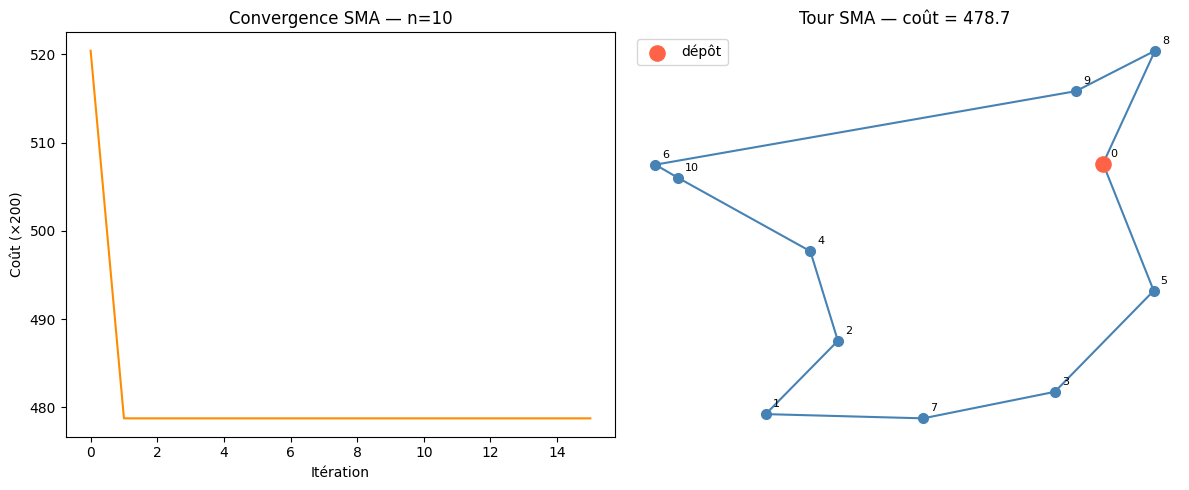

In [7]:
graph10 = Graph(cities10)
scale10 = meta10["scale"]   # 200.0

pop10 = Population(graph10, nb_agents=30, phase_length=15, opt_ratio=0.25)
tour10, raw10, history10, elapsed10 = pop10.run(T=200)

cost10 = round(raw10 * scale10, 1)
print(f"Coût SMA (×200) : {cost10}  |  itérations : {len(history10)}  |  t={elapsed10:.2f}s")

# ── Visualisation convergence + tour ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Convergence
ax1.plot([c * scale10 for c in history10], color="darkorange", lw=1.5)
ax1.set_xlabel("Itération")
ax1.set_ylabel("Coût (×200)")
ax1.set_title("Convergence SMA — n=10")

# Tour
cities = graph10.cities
xs = [cities[i][0] for i in tour10] + [cities[tour10[0]][0]]
ys = [cities[i][1] for i in tour10] + [cities[tour10[0]][1]]
ax2.plot(xs, ys, "-o", color="steelblue", ms=7, lw=1.5)
ax2.scatter(cities[0][0], cities[0][1], s=120, color="tomato", zorder=5, label="dépôt")
for i, (x, y) in enumerate(cities):
    ax2.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax2.set_title(f"Tour SMA — coût = {cost10}")
ax2.legend()
ax2.axis("off")

plt.tight_layout()
plt.show()

---
## 4. Benchmark — toutes les tailles

| Taille | Population | Itérations max | Limite temps |
|--------|-----------|---------------|-------------|
| $n \leq 100$ | 30 | 300 | — |
| $n \leq 500$ | 20 | 150 | 30 s |
| $n > 500$ | 15 | 80 | 60 s |

Les instances $n \geq 10\,000$ sont ignorées (trop lentes en Python pur).

In [8]:
def _sma_params(n: int) -> tuple[int, int, float | None]:
    """Retourne (nb_agents, T, time_limit) selon la taille de l'instance."""
    if n <= 100:
        return 30, 300, None
    if n <= 500:
        return 20, 150, 30.0
    return 15, 80, 60.0


def nn_cost_raw(graph: Graph) -> float:
    """Nearest-Neighbor depuis le dépôt (index 0) — coût brut."""
    n = graph.n
    visited = [False] * n
    tour = [0]
    visited[0] = True
    for _ in range(n - 1):
        last = tour[-1]
        nearest = min(
            (j for j in range(n) if not visited[j]),
            key=lambda j: graph.distance(last, j),
        )
        tour.append(nearest)
        visited[nearest] = True
    return graph.turn_cost(tour)


SKIP_N = 10_000

dataset_files = sorted(
    DATASETS_DIR.glob("tsptwd_n*.json"),
    key=lambda p: int(p.stem.split("_n")[1]),
)

results = []

for path in dataset_files:
    graph, meta = Graph.from_json(path)
    n     = meta["n_clients"]
    scale = meta["scale"]

    if n >= SKIP_N:
        print(f"n={n:>6}  [SKIP]")
        continue

    nb_agents, T, time_limit = _sma_params(n)

    # ── NN baseline ────────────────────────────────────────────────────
    cost_nn = round(nn_cost_raw(graph) * scale, 1)

    # ── SMA ────────────────────────────────────────────────────────────
    random.seed(42)
    pop = Population(graph, nb_agents=nb_agents)
    _, raw_sma, history, elapsed = pop.run(T=T, time_limit=time_limit)
    cost_sma = round(raw_sma * scale, 1)

    gain = round((cost_nn - cost_sma) / cost_nn * 100, 2)
    print(
        f"n={n:>6}  SMA={cost_sma:>9.1f}  NN={cost_nn:>9.1f}"
        f"  gain={gain:+.2f}%  iters={len(history):>4}  t={elapsed:.2f}s"
    )

    results.append({
        "n":         n,
        "cost_sma":  cost_sma,
        "cost_nn":   cost_nn,
        "gain_%":    gain,
        "iters":     len(history),
        "elapsed_s": round(elapsed, 3),
    })

n=    10  SMA=    478.7  NN=    535.3  gain=+10.57%  iters=  16  t=0.00s
n=    50  SMA=   1311.8  NN=   1479.2  gain=+11.32%  iters=  31  t=0.06s
n=   100  SMA=   1659.4  NN=   2033.5  gain=+18.40%  iters=  46  t=0.26s
n=   200  SMA=   2217.7  NN=   2705.2  gain=+18.02%  iters=  61  t=1.06s
n=   300  SMA=   2827.6  NN=   3505.1  gain=+19.33%  iters=  91  t=6.24s
n=   500  SMA=   3485.3  NN=   4240.2  gain=+17.80%  iters= 134  t=30.23s
n=  1000  SMA=   5313.9  NN=   5624.1  gain=+5.52%  iters=  80  t=14.01s
n= 10000  [SKIP]


In [9]:
df = pd.DataFrame(results).set_index("n")
display(df)

,cost_sma,cost_nn,gain_%,iters,elapsed_s
n,,,,,
10,478.7,535.3,10.57,16,0.004
50,1311.8,1479.2,11.32,31,0.057
100,1659.4,2033.5,18.40,46,0.262
200,2217.7,2705.2,18.02,61,1.065
300,2827.6,3505.1,19.33,91,6.244
500,3485.3,4240.2,17.80,134,30.233
1000,5313.9,5624.1,5.52,80,14.008


---
## 5. Visualisation des résultats

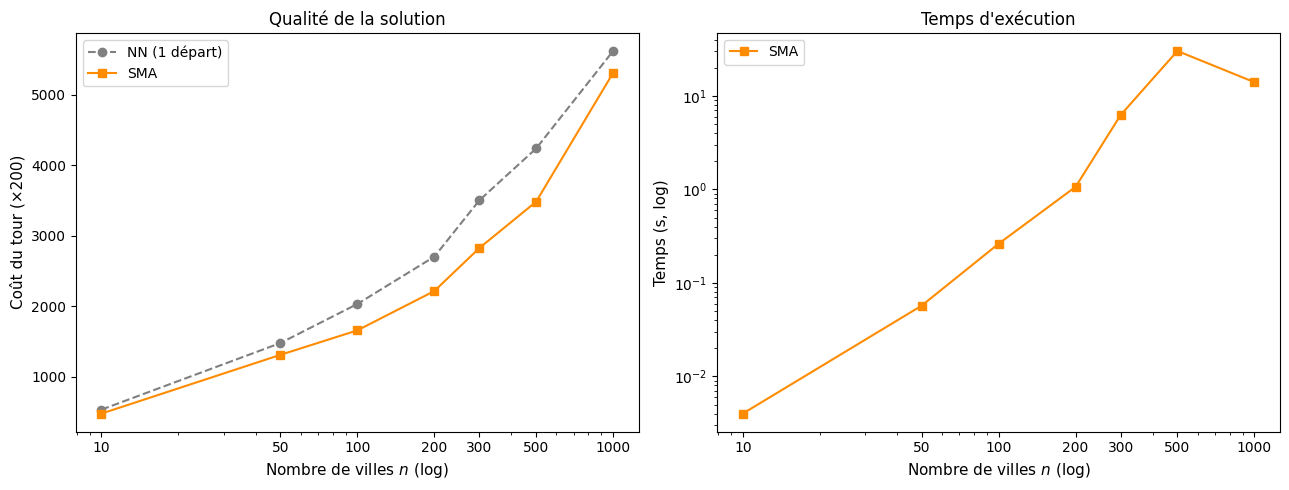

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ns = df.index.tolist()

# ── Qualité ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(ns, df["cost_nn"],  "o--", label="NN (1 départ)", color="gray")
ax.plot(ns, df["cost_sma"], "s-",  label="SMA",           color="darkorange")
ax.set_xscale("log")
ax.set_xlabel("Nombre de villes $n$ (log)", fontsize=11)
ax.set_ylabel("Coût du tour (×200)", fontsize=11)
ax.set_title("Qualité de la solution", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(ns)

# ── Temps ─────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(ns, df["elapsed_s"], "s-", color="darkorange", label="SMA")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Nombre de villes $n$ (log)", fontsize=11)
ax.set_ylabel("Temps (s, log)", fontsize=11)
ax.set_title("Temps d'exécution", fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(ns)

plt.tight_layout()
plt.show()